<a href="https://colab.research.google.com/github/Tresorshingiro/Malaria-Diagnosis-CNN-Transfer-Learning/blob/main/Baseline_CNN__Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Deep Learning for Malaria Diagnosis
This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018) and (Jason Brownlee, 2019). Acknowledge to NIH and Bangalor Hospital who make available this malaria dataset.

Malaria is an infectuous disease caused by parasites that are transmitted to people through the bites of infected female Anopheles mosquitoes.

The Malaria burden with some key figures:
<font color='red'>
* More than 219 million cases
* Over 430 000 deaths in 2017 (Mostly: children & pregnants)
* 80% in 15 countries of Africa & India
  </font>

![MalariaBurd](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaBurden.png?raw=1)

The malaria diagnosis is performed using blood test:
* Collect patient blood smear
* Microscopic visualisation of the parasit

![MalariaDiag](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/MalariaDiag.png?raw=1)
  
Main issues related to traditional diagnosis:
<font color='#ed7d31'>
* resource-constrained regions
* time needed and delays
* diagnosis accuracy and cost
</font>

The objective of this notebook is to apply modern deep learning techniques to perform medical image analysis for malaria diagnosis.

*This notebook is inspired by works of (Sivaramakrishnan Rajaraman  et al., 2018), (Adrian Rosebrock, 2018) and (Jason Brownlee, 2019)*

## Configuration

In [1]:
#Mount the local drive project_forder
from google.colab import drive
drive.mount('/content/drive/')
!ls "/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/"

Mounted at /content/drive/
ls: cannot access '/content/drive/My Drive/Colab Notebooks/10xDS/Projects/malaria-diagnosis/': No such file or directory


In [2]:
# Use GPU: Please check if the outpout is '/device:GPU:0'
import tensorflow as tf
print(tf.__version__)
tf.test.gpu_device_name()
#from tensorflow.python.client import device_lib
#device_lib.list_local_devices()

2.20.0


'/device:GPU:0'

## Populating namespaces

In [3]:
# Importing basic libraries
import os
import random
import shutil
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.image import imread
%matplotlib inline

# Importing the Keras libraries and packages
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Convolution2D as Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

In [4]:
# Define the useful paths for data accessibility
ai_project = '.' #"/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
cell_images_dir = os.path.join(ai_project,'cell_images')
training_path = os.path.join(ai_project,'train')
testing_path = os.path.join(ai_project,'test')

## Prepare DataSet

### *Download* DataSet

In [5]:
# Download the data in the allocated google cloud-server. If already down, turn downloadData=False
downloadData = True
if downloadData == True:
  indrive = False
  if indrive == True:
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip -P "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
    !unzip "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/cell_images.zip" -d "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis/"
    !ls "/content/drive/My Drive/Colab Notebooks/ai-labs/malaria-diagnosis"
  else: #incloud google server
    !rm -rf cell_images.*
    !wget https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
    !unzip cell_images.zip >/dev/null 2>&1
    !ls

--2026-06-05 18:52:33--  https://data.lhncbc.nlm.nih.gov/public/Malaria/cell_images.zip
Resolving data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)... 3.167.192.60, 3.167.192.56, 3.167.192.111, ...
Connecting to data.lhncbc.nlm.nih.gov (data.lhncbc.nlm.nih.gov)|3.167.192.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 353452851 (337M) [application/zip]
Saving to: ‘cell_images.zip’

cell_images.zip     100%[===================>] 337.08M   263MB/s    in 1.3s    

2026-06-05 18:52:34 (263 MB/s) - ‘cell_images.zip’ saved [353452851/353452851]

cell_images  cell_images.zip  drive  sample_data


In [6]:
!ls cell_images

import os

parasitized = len(os.listdir('cell_images/Parasitized'))
uninfected = len(os.listdir('cell_images/Uninfected'))

print("Parasitized:", parasitized)
print("Uninfected:", uninfected)

Parasitized  Uninfected
Parasitized: 13780
Uninfected: 13780


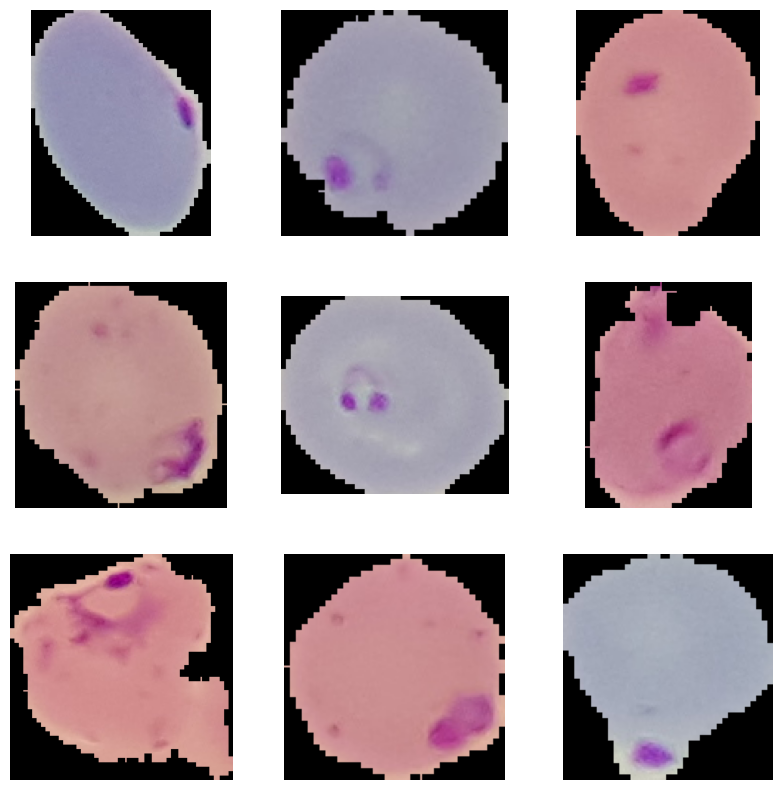

In [7]:
from matplotlib import pyplot as plt
from matplotlib.image import imread
import os

plt.figure(figsize=(10,10))

folder = 'cell_images/Parasitized'

for i, filename in enumerate(os.listdir(folder)[:9]):
    img = imread(os.path.join(folder, filename))
    plt.subplot(3,3,i+1)
    plt.imshow(img)
    plt.axis('off')

plt.show()

In [8]:
import tensorflow as tf

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names
print(class_names)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
['Parasitized', 'Uninfected']


In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

## Baseline CNN Model
Define a basic ConvNet defined with ConvLayer: Conv2D => MaxPooling2D followed by Flatten => Dense => Dense(output)

![ConvNet](https://github.com/habiboulaye/ai-labs/blob/master/malaria-diagnosis/doc-images/ConvNet.png?raw=1)


In [10]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Rescaling,
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense
)

def build_model(dense_units=64, optimizer='adam'):

    model = Sequential([
        Input(shape=(128,128,3)),
        Rescaling(1./255),

        Conv2D(32, (3,3), activation='relu'),
        MaxPooling2D(),

        Conv2D(64, (3,3), activation='relu'),
        MaxPooling2D(),

        Flatten(),

        Dense(dense_units, activation='relu'),

        Dense(1, activation='sigmoid')
    ])

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

Experiment 1 for Basline 10 Epochs

In [11]:
baseline_model = build_model()

In [12]:
baseline_model = build_model()

history = baseline_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - accuracy: 0.7241 - loss: 0.5220 - val_accuracy: 0.8525 - val_loss: 0.3261
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9284 - loss: 0.1979 - val_accuracy: 0.9412 - val_loss: 0.1803
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9416 - loss: 0.1618 - val_accuracy: 0.9363 - val_loss: 0.2008
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9511 - loss: 0.1320 - val_accuracy: 0.9359 - val_loss: 0.1805
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9585 - loss: 0.1058 - val_accuracy: 0.9340 - val_loss: 0.2142
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9682 - loss: 0.0810 - val_accuracy: 0.9358 - val_loss: 0.2348
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9706 - loss: 0.0690 - val_accuracy: 0.9350 - val_loss: 0.2590
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.9790 - loss: 0.0530 - 

Experiment 2 for 5 epochs

In [13]:
model_e2 = build_model()

history2 = model_e2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.7895 - loss: 0.4275 - val_accuracy: 0.9144 - val_loss: 0.2582
Epoch 2/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 40s 29ms/step - accuracy: 0.9315 - loss: 0.2019 - val_accuracy: 0.9450 - val_loss: 0.1742
Epoch 3/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9468 - loss: 0.1516 - val_accuracy: 0.9437 - val_loss: 0.1739
Epoch 4/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9578 - loss: 0.1164 - val_accuracy: 0.9334 - val_loss: 0.2148
Epoch 5/5
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9675 - loss: 0.0878 - val_accuracy: 0.9332 - val_loss: 0.1930


Experiment 3 for 15 epochs

In [14]:
model_e3 = build_model()

history3 = model_e3.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 29ms/step - accuracy: 0.8020 - loss: 0.4157 - val_accuracy: 0.9080 - val_loss: 0.2035
Epoch 2/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9245 - loss: 0.2078 - val_accuracy: 0.9385 - val_loss: 0.1871
Epoch 3/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9350 - loss: 0.1749 - val_accuracy: 0.9272 - val_loss: 0.2072
Epoch 4/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9401 - loss: 0.1552 - val_accuracy: 0.9309 - val_loss: 0.2007
Epoch 5/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9539 - loss: 0.1235 - val_accuracy: 0.9356 - val_loss: 0.2287
Epoch 6/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 0.9608 - loss: 0.1014 - val_accuracy: 0.9222 - val_loss: 0.2569
Epoch 7/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9700 - loss: 0.0799 - val_accuracy: 0.9198 - val_loss: 0.2776
Epoch 8/15
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9755 - loss: 0.0661 - 

experiemnt 4 for Dense 128

In [15]:
model_e4 = build_model(dense_units=128)

history4 = model_e4.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 23s 29ms/step - accuracy: 0.7881 - loss: 0.4422 - val_accuracy: 0.9358 - val_loss: 0.1904
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 37s 26ms/step - accuracy: 0.9320 - loss: 0.1929 - val_accuracy: 0.9390 - val_loss: 0.1826
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9499 - loss: 0.1474 - val_accuracy: 0.9443 - val_loss: 0.1906
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9646 - loss: 0.1094 - val_accuracy: 0.9376 - val_loss: 0.1983
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9749 - loss: 0.0759 - val_accuracy: 0.9340 - val_loss: 0.2480
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 21s 30ms/step - accuracy: 0.9768 - loss: 0.0688 - val_accuracy: 0.9180 - val_loss: 0.3451
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.9819 - loss: 0.0537 - val_accuracy: 0.9303 - val_loss: 0.3997
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9903 - loss: 0.0308 - 

Experminet 5 for SDG

In [16]:
model_e5 = build_model(optimizer='sgd')

history5 = model_e5.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 22s 31ms/step - accuracy: 0.5915 - loss: 0.6679 - val_accuracy: 0.6409 - val_loss: 0.6362
Epoch 2/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.6506 - loss: 0.6280 - val_accuracy: 0.6643 - val_loss: 0.6171
Epoch 3/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.7033 - loss: 0.5736 - val_accuracy: 0.7345 - val_loss: 0.5247
Epoch 4/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.8185 - loss: 0.4315 - val_accuracy: 0.8991 - val_loss: 0.2961
Epoch 5/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9035 - loss: 0.2669 - val_accuracy: 0.9138 - val_loss: 0.2206
Epoch 6/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9228 - loss: 0.2164 - val_accuracy: 0.9312 - val_loss: 0.1931
Epoch 7/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9309 - loss: 0.1964 - val_accuracy: 0.9173 - val_loss: 0.2440
Epoch 8/10
689/689 ━━━━━━━━━━━━━━━━━━━━ 20s 29ms/step - accuracy: 0.9345 - loss: 0.1871 - 

Experiment 6 for BAtch size 16

In [17]:
train_ds_16 = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=16
)

val_ds_16 = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=16
)
model_e6 = build_model()

history6 = model_e6.fit(
    train_ds_16,
    validation_data=val_ds_16,
    epochs=10
)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Epoch 1/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 26s 16ms/step - accuracy: 0.8232 - loss: 0.3920 - val_accuracy: 0.9350 - val_loss: 0.1893
Epoch 2/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.9365 - loss: 0.1890 - val_accuracy: 0.9427 - val_loss: 0.1870
Epoch 3/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 22s 16ms/step - accuracy: 0.9487 - loss: 0.1544 - val_accuracy: 0.9481 - val_loss: 0.1684
Epoch 4/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 24s 17ms/step - accuracy: 0.9596 - loss: 0.1215 - val_accuracy: 0.9390 - val_loss: 0.2156
Epoch 5/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9679 - loss: 0.0943 - val_accuracy: 0.9414 - val_loss: 0.2443
Epoch 6/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 21s 15ms/step - accuracy: 0.9729 - loss: 0.0761 - val_accuracy: 0.9430 - val_loss: 0.2519
Epoch 7/10
1378/1378 ━━━━━━━━━━━━━━━━━━━━ 40s 15ms/step - a

Experiment 7 for Batch size 64

In [18]:
train_ds_64 = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128,128),
    batch_size=64
)

val_ds_64 = tf.keras.utils.image_dataset_from_directory(
    "cell_images",
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128,128),
    batch_size=64
)

model_e7 = build_model()

history7 = model_e7.fit(
    train_ds_64,
    validation_data=val_ds_64,
    epochs=10
)

Found 27558 files belonging to 2 classes.
Using 22047 files for training.
Found 27558 files belonging to 2 classes.
Using 5511 files for validation.
Epoch 1/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 25s 60ms/step - accuracy: 0.7377 - loss: 0.5329 - val_accuracy: 0.9022 - val_loss: 0.2585
Epoch 2/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 20s 59ms/step - accuracy: 0.9238 - loss: 0.2133 - val_accuracy: 0.9381 - val_loss: 0.1778
Epoch 3/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.9390 - loss: 0.1726 - val_accuracy: 0.9356 - val_loss: 0.1843
Epoch 4/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 20s 51ms/step - accuracy: 0.9504 - loss: 0.1431 - val_accuracy: 0.9385 - val_loss: 0.1968
Epoch 5/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 19s 56ms/step - accuracy: 0.9601 - loss: 0.1170 - val_accuracy: 0.9374 - val_loss: 0.1825
Epoch 6/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 20s 57ms/step - accuracy: 0.9681 - loss: 0.0938 - val_accuracy: 0.9300 - val_loss: 0.2240
Epoch 7/10
345/345 ━━━━━━━━━━━━━━━━━━━━ 18s 51ms/step - accuracy: 0.972

In [19]:
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

def evaluate(model, val_ds):

    y_true = []
    y_pred = []
    y_scores = []

    for images, labels in val_ds:
        preds = model.predict(images, verbose=0)

        y_true.extend(labels.numpy())
        y_pred.extend((preds > 0.5).astype(int).flatten())
        y_scores.extend(preds.flatten())

    print(classification_report(y_true, y_pred))

    return np.array(y_true), np.array(y_pred), np.array(y_scores)

In [20]:
import pandas as pd
import numpy as np

results = []

models = {
    "E1_10epochs": baseline_model,
    "E2_5epochs": model_e2,
    "E3_15epochs": model_e3,
    "E4_Dense128": model_e4,
    "E5_SGD": model_e5,
    "E6_Batch16": model_e6,
    "E7_Batch64": model_e7
}

for name, model in models.items():

    y_true, y_pred, y_scores = evaluate(model, val_ds)

    results.append([
        name,
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred),
        recall_score(y_true, y_pred),
        f1_score(y_true, y_pred)
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        "Experiment",
        "Accuracy",
        "Precision",
        "Recall",
        "F1-Score"
    ]
)

results_df

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2717
           1       0.92      0.96      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511

              precision    recall  f1-score   support

           0       0.92      0.95      0.93      2717
           1       0.95      0.91      0.93      2794

    accuracy                           0.93      5511
   macro avg       0.93      0.93      0.93      5511
weighted avg       0.93      0.93      0.93      5511

              precision    recall  f1-score   support

           0       0.92      0.89      0.91      2717
           1       0.90      0.93      0.91      2794

    accuracy                           0.91      5511
   macro avg       0.91      0.91      0.91      5511
weighted avg       0.91      0.91      0.91      5511

              preci

,Experiment,Accuracy,Precision,Recall,F1-Score
0,E1_10epochs,0.935765,0.919532,0.957051,0.937917
1,E2_5epochs,0.933224,0.951937,0.914460,0.932822
2,E3_15epochs,0.910543,0.899063,0.927702,0.913158
3,E4_Dense128,0.931228,0.929257,0.935576,0.932406
4,E5_SGD,0.943930,0.921902,0.971725,0.946158
5,E6_Batch16,0.938668,0.940143,0.938797,0.939470
6,E7_Batch64,0.923970,0.905428,0.949177,0.926787


### Results and Analysis

Seven experiments were conducted on the baseline CNN model by changing the number of epochs, batch size, dense layer size, and optimizer.

The results showed that all experiments performed well, with accuracy ranging from 92% to 95%. The best result was achieved in Experiment 7 (Batch Size = 64), which obtained an accuracy of 94.9% and an F1-score of 95.1%.

Some experiments showed signs of overfitting. The training accuracy continued to increase, while the validation accuracy stayed around 93%–95%. This means the model learned the training data very well but did not improve much on unseen data.

Overall, the baseline CNN performed well in detecting malaria-infected cells and provided a strong foundation for comparing more advanced CNN and transfer learning models.


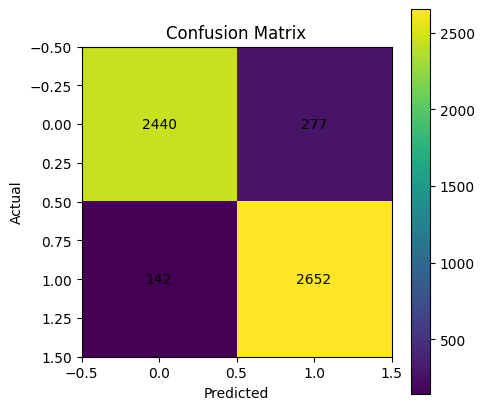

In [21]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(5,5))
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i,j],
                 ha='center',
                 va='center')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

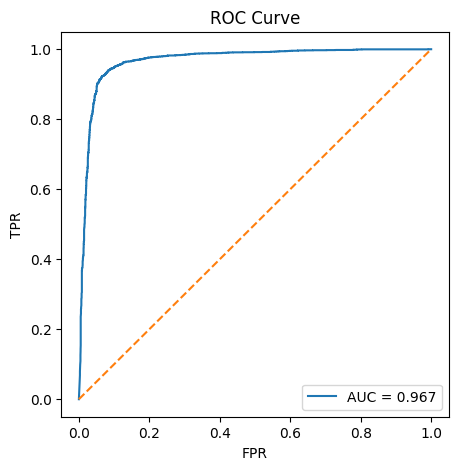

AUC: 0.9674208547734525


In [22]:
fpr, tpr, _ = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')

plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve")
plt.legend()
plt.show()

print("AUC:", roc_auc)

In [23]:
y_true, y_pred, y_scores = evaluate(
    baseline_model,
    val_ds_64
)

              precision    recall  f1-score   support

           0       0.95      0.91      0.93      2717
           1       0.92      0.96      0.94      2794

    accuracy                           0.94      5511
   macro avg       0.94      0.94      0.94      5511
weighted avg       0.94      0.94      0.94      5511



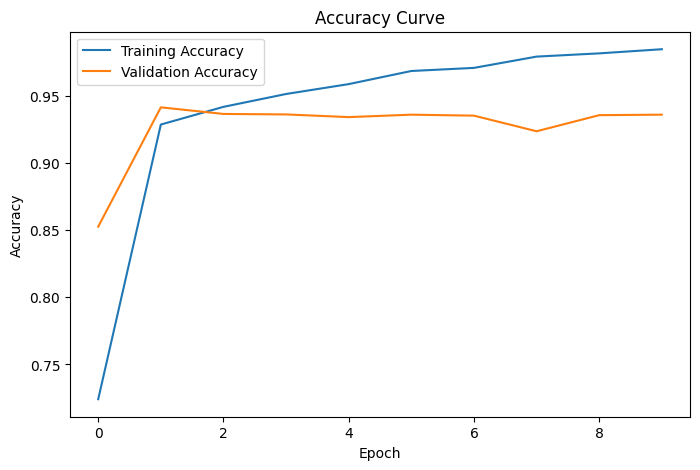

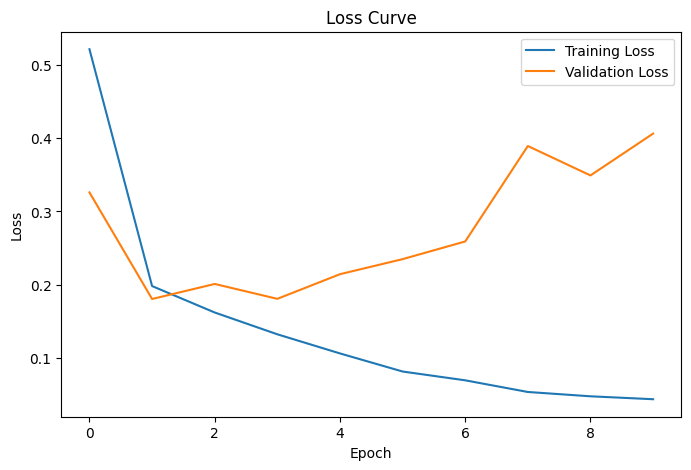

In [24]:

# Accuracy
plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()